In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import itertools

# Set pandas options for nice tables with only 2 decimals : 
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [3]:
def coord_id_assign(selected_coord,grid_system,lat_range,long_range) :
    """
    Returns the grid id value based on the latitude and longitude inputs.
    
        No checks were implemented against negative latitude values. Range should be 0 to 180 degrees (lon) 
        or 90 degrees (lat).
        
        selected_coord is in the format "latitude, longitude", as in : selected_coord = (lat,long)
        
    """
    y = selected_coord[0]
    x = selected_coord[1]

    
    # Check that the selected coordinates fit the grid-system : 
    if x < np.amin(long_range) or x > np.amax(long_range) :
        raise ValueError ('The longitude coordinate exceeded the range!')
            
    if y < np.amin(lat_range) or y > np.amax(lat_range) :
        raise ValueError ('The latitude coordinate exceeded the range!')
        
    # Ensure that if a datapoint is exactly on the far left edge, it still is accounted for : 
    if x == np.amax(long_range) :
        x= x-0.000001
    
    # Ensure that if a datapoint is exactly on the admitted latitude, it still is accounted for : 
    if y == np.amax(lat_range) : 
        y = y-0.000001 
    
    x_id = np.digitize(x,long_range,right = False)
    y_id = np.digitize(y,lat_range,right= False)
    cell_val = grid_system[-y_id,-x_id]
    
    return(cell_val)

def center_cell_coord(coords) : 
    
    """
    Returns a list of intermediate coordinates (middle of the cell values)
    coords = (min_lat,max_lat,lat_grids_spacing,min_long,max_long,long_grids_spacing)
    
    """
    
    min_lat = coords[0]
    max_lat = coords[1]
    lat_grids_spacing = coords[2]
    nb_lat_cells = int((max_lat-min_lat)/lat_grids_spacing)
    
    
    min_long = coords[3]
    max_long = coords[4]
    long_grids_spacing = coords[5]
    nb_long_cells = int((max_long-min_long)/long_grids_spacing)
    
    vc_array = np.linspace((min_lat+lat_grids_spacing/2),(max_lat-lat_grids_spacing/2),int(nb_lat_cells))
    hc_array = np.linspace((min_long+long_grids_spacing/2),(max_long-long_grids_spacing/2),int(nb_long_cells))
    
    print('vertical_array :', vc_array)
    print('horizontal_array ',hc_array)
    
    list_pairs = []
    
    for pair in itertools.product(vc_array, hc_array):
        list_pairs.append(pair)
        
    return(list_pairs)

In [4]:
# Setting the grid system : 
# Longitude :
min_lat = 10 # degree
max_lat = 60 # degree
lat_grids = 5 # degree

# Latitude : 
min_long = 0 # degree
max_long = 110 # degree
long_grids = 5 # degree

# Grid info
grid_width = max_long-min_long
grid_height = max_lat-min_lat
nb_width_cell = int(grid_width/long_grids)
nb_height_cell = int(grid_height/lat_grids)
nb_cells = int((nb_width_cell)*(nb_height_cell))

long_range = np.linspace(min_long,max_long,int(nb_width_cell+1))
lat_range = np.linspace(min_lat,max_lat,int(nb_height_cell+1))

print('The longitude range is : \n',long_range,'\nThe latitude range is : \n',lat_range)

The longitude range is : 
 [  0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100. 105. 110.] 
The latitude range is : 
 [10. 15. 20. 25. 30. 35. 40. 45. 50. 55. 60.]


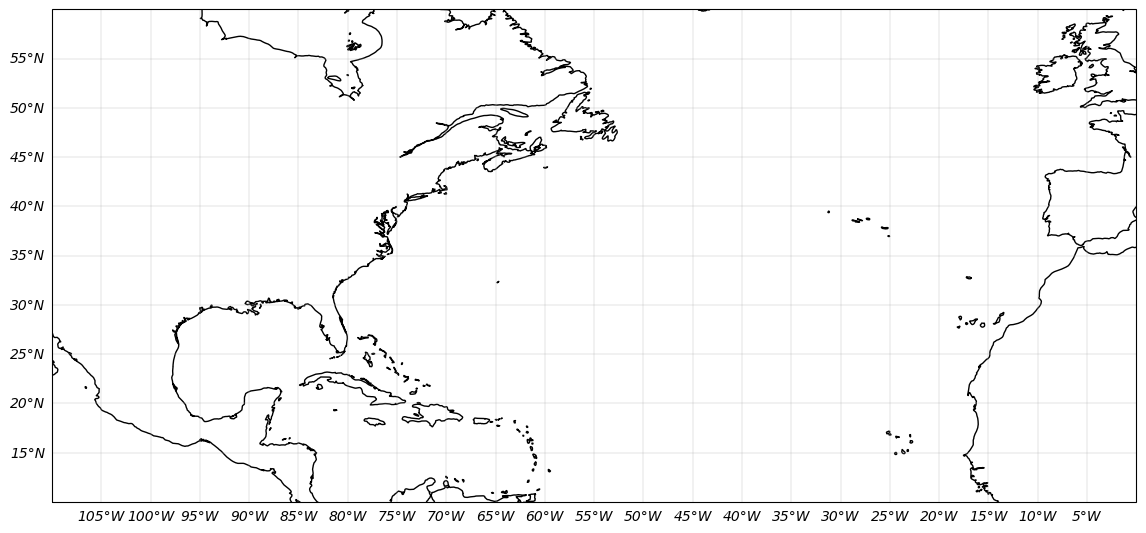

In [5]:
# Bit of a visual background information on the grid we're playing with : 
fig_width = 16
fig_height = (4/10)*fig_width
fig = plt.figure(figsize=(fig_width,fig_height))
ax = plt.axes(projection=ccrs.PlateCarree()) 
ax.set_extent([-max_long, min_long, min_lat, max_lat], crs = ccrs.PlateCarree()) 
gl = ax.gridlines(xlocs = -long_range, ylocs = lat_range, draw_labels=True,linewidth=0.25)
gl.top_labels = False
gl.right_labels = False
ax.coastlines()

In [6]:
# Creating ids for the grid-cells : 
# Create an vector, format into a suitable matrix, order so that (0,0) is the bottom left corner.
cell_ids = np.flip(np.arange(1,nb_cells+1).reshape(nb_height_cell,nb_width_cell),0)

In [7]:
# Loading the modified HURDAT2 data : 
edited_atlantic_storms = pd.read_csv("edited_atlantic_storms.csv")
edited_atlantic_storms.head(5) # 5 first rows within the dataframe.

,index,id,name,date,record_identifier,status_of_system,latitude,longitude,maximum_sustained_wind_knots,maximum_pressure,...,Int_im1,Int_im2,Int_ip1,SST_p1,ln_Int,ln_Int_im1,ln_Int_im2,ln_Int_ip1,delta_SST,pc_comp
0,0,AL011851,UNNAMED,1851-06-25 00:00:00,NaN,HU,28.00,-94.80,80,NaN,...,NaN,NaN,0.06,301.10,-2.87,NaN,NaN,-2.87,-0.07,974.27
1,1,AL011851,UNNAMED,1851-06-25 06:00:00,NaN,HU,28.00,-95.40,80,NaN,...,0.06,NaN,0.06,301.03,-2.87,-2.87,NaN,-2.87,-0.07,974.27
2,2,AL011851,UNNAMED,1851-06-25 12:00:00,NaN,HU,28.00,-96.00,80,NaN,...,0.06,0.06,0.06,300.98,-2.87,-2.87,-2.87,-2.87,-0.05,974.27
3,3,AL011851,UNNAMED,1851-06-25 18:00:00,NaN,HU,28.10,-96.50,80,NaN,...,0.06,0.06,0.06,300.98,-2.87,-2.87,-2.87,-2.87,0.00,974.06
4,4,AL011851,UNNAMED,1851-06-25 21:00:00,L,HU,28.20,-96.80,80,NaN,...,0.06,0.06,NaN,NaN,-2.87,-2.87,-2.87,NaN,NaN,974.24


In [8]:
#Subset the latitude and longitude values in the dataframe : 
lat_long_array = edited_atlantic_storms[['latitude','longitude']].values
lat_long_array[:,1] = lat_long_array[:,1]*-1 # take the positive values

In [9]:
# Small report on the datasets that are getting clipped : 
vert_min_exceeded = lat_long_array[np.where(lat_long_array[:,0] < min_lat)]
vert_max_exceeded = lat_long_array[np.where(lat_long_array[:,0]>max_lat)]
lateral_min_exceeded = lat_long_array[np.where(lat_long_array[:,1]<min_long)]
lateral_max_exceeded = lat_long_array[np.where(lat_long_array[:,1]>max_long)]

print('Number of datasets exceeding the bounded area :')
print('Bottom latitude boundary :',len(vert_min_exceeded))
print('Top latitude boundary :',len(vert_max_exceeded))
print('Bottom longitude boundary :',len(lateral_min_exceeded))
print('Top longitude boundary :',len(lateral_max_exceeded))

# Note : Sensitivity could be investigated regarding the bottom boundary of the grid

Number of datasets exceeding the bounded area :
Bottom latitude boundary : 262
Top latitude boundary : 296
Bottom longitude boundary : 81
Top longitude boundary : 0


In [10]:
# Clip the data that do not fit the experiment : 
edited_atlantic_storms = edited_atlantic_storms[edited_atlantic_storms.latitude > min_lat]
edited_atlantic_storms = edited_atlantic_storms[edited_atlantic_storms.latitude < max_lat]

# Recall that longitudes are negative values in the atlantic area :
edited_atlantic_storms = edited_atlantic_storms[edited_atlantic_storms.longitude < min_long]
edited_atlantic_storms = edited_atlantic_storms[edited_atlantic_storms.longitude > -max_long]

In [11]:
#Subset the latitude and longitude values in the dataframe for the 2nd time : 
lat_long_array = edited_atlantic_storms[['latitude','longitude']].values
lat_long_array[:,1] = lat_long_array[:,1]*-1 # take the positive values

In [12]:
# Small report on the datasets post-clipping : 
vert_min_exceeded = lat_long_array[np.where(lat_long_array[:,0] < min_lat)]
vert_max_exceeded = lat_long_array[np.where(lat_long_array[:,0]>max_lat)]
lateral_min_exceeded = lat_long_array[np.where(lat_long_array[:,1]<min_long)]
lateral_max_exceeded = lat_long_array[np.where(lat_long_array[:,1]>max_long)]

print('Number of datasets exceeding the bounded area :')
print('Bottom latitude boundary :',len(vert_min_exceeded))
print('Top latitude boundary :',len(vert_max_exceeded))
print('Bottom longitude boundary :',len(lateral_min_exceeded))
print('Top longitude boundary :',len(lateral_max_exceeded))

Number of datasets exceeding the bounded area :
Bottom latitude boundary : 0
Top latitude boundary : 0
Bottom longitude boundary : 0
Top longitude boundary : 0


In [13]:
# Bit slow, could be more pythonic...
numbered_cells = []
for pair in lat_long_array : 
    numbered_cells.append(coord_id_assign(pair,cell_ids,lat_range,long_range))

In [14]:
# Add cell ids to datasets :
edited_atlantic_storms['grid_ids'] = numbered_cells
# Re-format the indexing of the dataframe before saving : 
edited_atlantic_storms = edited_atlantic_storms.reset_index(drop = True)
edited_atlantic_storms = edited_atlantic_storms.drop(['index'], axis = 1)
display(edited_atlantic_storms)

,id,name,date,record_identifier,status_of_system,latitude,longitude,maximum_sustained_wind_knots,maximum_pressure,34_kt_ne,...,Int_im2,Int_ip1,SST_p1,ln_Int,ln_Int_im1,ln_Int_im2,ln_Int_ip1,delta_SST,pc_comp,grid_ids
0,AL011851,UNNAMED,1851-06-25 00:00:00,NaN,HU,28.00,-94.80,80,NaN,NaN,...,NaN,0.06,301.10,-2.87,NaN,NaN,-2.87,-0.07,974.27,70
1,AL011851,UNNAMED,1851-06-25 06:00:00,NaN,HU,28.00,-95.40,80,NaN,NaN,...,NaN,0.06,301.03,-2.87,-2.87,NaN,-2.87,-0.07,974.27,69
2,AL011851,UNNAMED,1851-06-25 12:00:00,NaN,HU,28.00,-96.00,80,NaN,NaN,...,0.06,0.06,300.98,-2.87,-2.87,-2.87,-2.87,-0.05,974.27,69
3,AL011851,UNNAMED,1851-06-25 18:00:00,NaN,HU,28.10,-96.50,80,NaN,NaN,...,0.06,0.06,300.98,-2.87,-2.87,-2.87,-2.87,0.00,974.06,69
4,AL011851,UNNAMED,1851-06-25 21:00:00,L,HU,28.20,-96.80,80,NaN,NaN,...,0.06,NaN,NaN,-2.87,-2.87,-2.87,NaN,NaN,974.24,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52023,AL302020,THETA,2020-11-15 12:00:00,NaN,LO,31.40,-18.30,30,1009.00,0.00,...,0.02,0.01,295.04,-4.59,-4.23,-4.09,-4.98,-0.10,1009.00,107
52024,AL302020,THETA,2020-11-15 18:00:00,NaN,LO,31.60,-18.00,30,1012.00,0.00,...,0.01,0.01,294.88,-4.98,-4.59,-4.23,-5.17,-0.17,1012.00,107
52025,AL302020,THETA,2020-11-16 00:00:00,NaN,LO,32.10,-17.90,30,1013.00,0.00,...,0.01,0.01,294.72,-5.17,-4.98,-4.59,-5.18,-0.16,1013.00,107
52026,AL302020,THETA,2020-11-16 06:00:00,NaN,LO,32.70,-18.20,25,1014.00,0.00,...,0.01,0.01,294.51,-5.18,-5.17,-4.98,-5.19,-0.21,1014.00,107


In [15]:
edited_atlantic_storms.to_csv('gridded_atlantic_storms.csv', index = False)
edited_atlantic_storms

,id,name,date,record_identifier,status_of_system,latitude,longitude,maximum_sustained_wind_knots,maximum_pressure,34_kt_ne,...,Int_im2,Int_ip1,SST_p1,ln_Int,ln_Int_im1,ln_Int_im2,ln_Int_ip1,delta_SST,pc_comp,grid_ids
0,AL011851,UNNAMED,1851-06-25 00:00:00,NaN,HU,28.00,-94.80,80,NaN,NaN,...,NaN,0.06,301.10,-2.87,NaN,NaN,-2.87,-0.07,974.27,70
1,AL011851,UNNAMED,1851-06-25 06:00:00,NaN,HU,28.00,-95.40,80,NaN,NaN,...,NaN,0.06,301.03,-2.87,-2.87,NaN,-2.87,-0.07,974.27,69
2,AL011851,UNNAMED,1851-06-25 12:00:00,NaN,HU,28.00,-96.00,80,NaN,NaN,...,0.06,0.06,300.98,-2.87,-2.87,-2.87,-2.87,-0.05,974.27,69
3,AL011851,UNNAMED,1851-06-25 18:00:00,NaN,HU,28.10,-96.50,80,NaN,NaN,...,0.06,0.06,300.98,-2.87,-2.87,-2.87,-2.87,0.00,974.06,69
4,AL011851,UNNAMED,1851-06-25 21:00:00,L,HU,28.20,-96.80,80,NaN,NaN,...,0.06,NaN,NaN,-2.87,-2.87,-2.87,NaN,NaN,974.24,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52023,AL302020,THETA,2020-11-15 12:00:00,NaN,LO,31.40,-18.30,30,1009.00,0.00,...,0.02,0.01,295.04,-4.59,-4.23,-4.09,-4.98,-0.10,1009.00,107
52024,AL302020,THETA,2020-11-15 18:00:00,NaN,LO,31.60,-18.00,30,1012.00,0.00,...,0.01,0.01,294.88,-4.98,-4.59,-4.23,-5.17,-0.17,1012.00,107
52025,AL302020,THETA,2020-11-16 00:00:00,NaN,LO,32.10,-17.90,30,1013.00,0.00,...,0.01,0.01,294.72,-5.17,-4.98,-4.59,-5.18,-0.16,1013.00,107
52026,AL302020,THETA,2020-11-16 06:00:00,NaN,LO,32.70,-18.20,25,1014.00,0.00,...,0.01,0.01,294.51,-5.18,-5.17,-4.98,-5.19,-0.21,1014.00,107


# Overlaying text or numbers on cells

In [16]:
gridded_atlantic_storms = pd.read_csv("gridded_atlantic_storms.csv")
print('There are',len(gridded_atlantic_storms),'datasets in this table.')
gridded_atlantic_storms.head(5)

There are 52028 datasets in this table.


,id,name,date,record_identifier,status_of_system,latitude,longitude,maximum_sustained_wind_knots,maximum_pressure,34_kt_ne,...,Int_im2,Int_ip1,SST_p1,ln_Int,ln_Int_im1,ln_Int_im2,ln_Int_ip1,delta_SST,pc_comp,grid_ids
0,AL011851,UNNAMED,1851-06-25 00:00:00,NaN,HU,28.00,-94.80,80,NaN,NaN,...,NaN,0.06,301.10,-2.87,NaN,NaN,-2.87,-0.07,974.27,70
1,AL011851,UNNAMED,1851-06-25 06:00:00,NaN,HU,28.00,-95.40,80,NaN,NaN,...,NaN,0.06,301.03,-2.87,-2.87,NaN,-2.87,-0.07,974.27,69
2,AL011851,UNNAMED,1851-06-25 12:00:00,NaN,HU,28.00,-96.00,80,NaN,NaN,...,0.06,0.06,300.98,-2.87,-2.87,-2.87,-2.87,-0.05,974.27,69
3,AL011851,UNNAMED,1851-06-25 18:00:00,NaN,HU,28.10,-96.50,80,NaN,NaN,...,0.06,0.06,300.98,-2.87,-2.87,-2.87,-2.87,0.00,974.06,69
4,AL011851,UNNAMED,1851-06-25 21:00:00,L,HU,28.20,-96.80,80,NaN,NaN,...,0.06,NaN,NaN,-2.87,-2.87,-2.87,NaN,NaN,974.24,69


In [17]:
# Setting the grid system : 
# Longitude :
min_lat = 10 # degree
max_lat = 60 # degree
lat_grids = 5 # degree

# Latitude : 
min_long = 0 # degree
max_long = 110 # degree
long_grids = 5 # degree

# Grid info
grid_width = max_long-min_long
grid_height = max_lat-min_lat
nb_width_cell = int(grid_width/long_grids)
nb_height_cell = int(grid_height/lat_grids)
nb_cells = int((nb_width_cell)*(nb_height_cell))

long_range = np.linspace(min_long,max_long,int(nb_width_cell+1))
lat_range = np.linspace(min_lat,max_lat,int(nb_height_cell+1))
cell_ids = np.flip(np.arange(1,nb_cells+1).reshape(nb_height_cell,nb_width_cell),0)

print('The longitude range is : \n',long_range,'\nThe latitude range is : \n',lat_range)

The longitude range is : 
 [  0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100. 105. 110.] 
The latitude range is : 
 [10. 15. 20. 25. 30. 35. 40. 45. 50. 55. 60.]


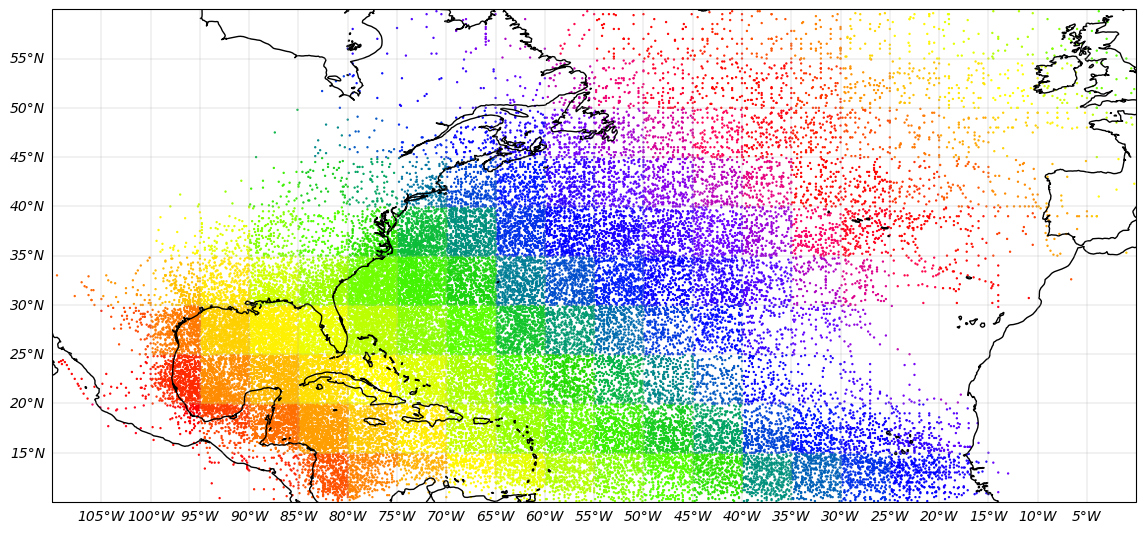

In [18]:
# Extracting the values : 
xc = gridded_atlantic_storms['longitude']
yc = gridded_atlantic_storms['latitude']
cc = gridded_atlantic_storms['grid_ids']

fig_width = 16
fig_height = (4/10)*fig_width
fig = plt.figure(figsize=(fig_width,fig_height))

ax = plt.axes(projection=ccrs.PlateCarree()) 

ax.set_extent([-max_long, min_long, min_lat, max_lat], crs = ccrs.PlateCarree()) 
gl = ax.gridlines(xlocs = -long_range, ylocs = lat_range, draw_labels=True,linewidth=0.25)

gl.top_labels = False
gl.right_labels = False


cm = plt.colormaps['prism']

sc = plt.scatter(xc, yc, c= cc, cmap = cm, marker='.', s=1.9 )
ax.coastlines()

In [19]:
# Lets add new layers of information on this data :

# 1st : Ability to display grid id labels and other info at the center of each cell : 
coords = (min_lat,max_lat,lat_grids,min_long,max_long,long_grids)
pairs = center_cell_coord(coords)

vertical_array : [12.5 17.5 22.5 27.5 32.5 37.5 42.5 47.5 52.5 57.5]
horizontal_array  [  2.5   7.5  12.5  17.5  22.5  27.5  32.5  37.5  42.5  47.5  52.5  57.5
  62.5  67.5  72.5  77.5  82.5  87.5  92.5  97.5 102.5 107.5]


In [20]:
trio_list = [] #
for coord in pairs :
    trio_list.append((coord_id_assign(coord,cell_ids,lat_range,long_range),coord[1],coord[0]))

In [21]:
numbers_df = pd.DataFrame(trio_list)
numbers_df.columns = ['grid_ids','longitude','latitude']
numbers_df = numbers_df.sort_values(by=['grid_ids'], ignore_index = True)
display(numbers_df)

,grid_ids,longitude,latitude
0,1,107.50,12.50
1,2,102.50,12.50
2,3,97.50,12.50
3,4,92.50,12.50
4,5,87.50,12.50
...,...,...,...
215,216,22.50,57.50
216,217,17.50,57.50
217,218,12.50,57.50
218,219,7.50,57.50


In [22]:
# 2nd : Ability to count the number of datasets available in each grid 

# Create a dictionary to compile all dataframes subsetted per cell id : 
df = {}
for i in range(nb_cells) : 
    ds_in_grid = gridded_atlantic_storms.loc[gridded_atlantic_storms['grid_ids'] == i+1]
    df[i+1] = pd.DataFrame(ds_in_grid)
    
# To get a quick look in table format: 
Visualize = False

if Visualize == True : 
    for ids, dataframe in df.items() : 
        display(dataframe)

In [23]:
# 3rd : Ability to split easterly and westerly datasets, per grid :  

# Create a dictionary to compile all dataframes subsetted per cell id and direction (west versus east) : 
df_W = {}
df_E = {}

for i in range(nb_cells) : 
    ds_in_grid = gridded_atlantic_storms.loc[gridded_atlantic_storms['grid_ids'] == i+1]
    west_ds = ds_in_grid[ds_in_grid['E_or_W']== 'W']
    east_ds = ds_in_grid[ds_in_grid['E_or_W']== 'E']

    df_W[i+1] = pd.DataFrame(west_ds)
    df_E[i+1] = pd.DataFrame(east_ds)

    
    
# To get a quick look in table format: 
Visualize_west = False
Visualize_east = False

if Visualize_west == True : 
    for ids, dataframe in df_W.items() : 
        display(dataframe)
        
if Visualize_east == True : 
    for ids, dataframe in df_E.items() : 
        display(dataframe)

In [24]:
# Find out how many records per cell : 
record_per_cells = np.empty([1]) # Just a place holder - will be deleted later.
record_per_west_cells = np.empty([1]) # same as previous
record_per_east_cells = np.empty([1]) # same as previous


for ids in range(nb_cells) :
    # Records per cells :
    record_IN_cell = np.array([df[ids+1].shape[0]])
    record_per_cells = np.append(record_per_cells,record_IN_cell) 
    # Records per west cells : 
    record_IN_west_cell = np.array([df_W[ids+1].shape[0]])
    record_per_west_cells = np.append(record_per_west_cells,record_IN_west_cell) 
    # Records per east cells : 
    record_IN_east_cell = np.array([df_E[ids+1].shape[0]])
    record_per_east_cells = np.append(record_per_east_cells,record_IN_east_cell)     
    
# Delete the place holders     
record_per_cells = np.delete(record_per_cells,0,0)
record_per_west_cells = np.delete(record_per_west_cells,0,0)
record_per_east_cells = np.delete(record_per_east_cells,0,0)


numbers_df['record_per_cell'] = record_per_cells.astype('int')
numbers_df['record_per_west_cell'] = record_per_west_cells.astype('int')
numbers_df['record_per_east_cell'] = record_per_east_cells.astype('int')

# Liu 2014 (thesis) suggest coefficient regression will only work properly if record per cell > 6. 
# Thus, explicitly discerning cells with 6 or more records : 

numbers_df['sufficient_records_west'] = ['y' if x >= 6 else 'n' for x in numbers_df['record_per_west_cell']]
numbers_df['sufficient_records_east'] = ['y' if x >= 6 else 'n' for x in numbers_df['record_per_east_cell']]

# Save to csv file : 
numbers_df.to_csv('grid_data.csv', index = False)

display(numbers_df)

,grid_ids,longitude,latitude,record_per_cell,record_per_west_cell,record_per_east_cell,sufficient_records_west,sufficient_records_east
0,1,107.50,12.50,0,0,0,n,n
1,2,102.50,12.50,0,0,0,n,n
2,3,97.50,12.50,1,1,0,n,n
3,4,92.50,12.50,25,19,6,y,y
4,5,87.50,12.50,56,56,0,y,n
...,...,...,...,...,...,...,...,...
215,216,22.50,57.50,28,4,24,n,y
216,217,17.50,57.50,19,3,16,n,y
217,218,12.50,57.50,18,1,17,n,y
218,219,7.50,57.50,18,0,18,n,y
